# Lagged & Cumulative Heat Exposure → Buffalo Traits

**Question.** Milk recorded on a test-day reflects the *preceding* days/weeks, and heat stress accumulates. So instead of same-day THI, we ask: **over what timescale does heat exposure affect each trait, and how strongly?**

**Method (built on the validated pipeline in `Climate_Signal_Validation.ipynb`):**
- Heat = **THI_1 anomaly** (daily-max THI_1 minus each farm's month-normal) — removes the season confound that made raw THI show the wrong sign.
- For each window W (1…90 days) we average the daily anomaly over the **trailing W days** on each farm's series, then attach it to the test-day. This is the *accumulated excess heat* the animal experienced going into the record.
- Effect = **within-animal slope** (animal fixed effect) with **farm-clustered SE**, **summer only**, and — crucially — **with DIM+parity controlled**, because longer windows correlate with later lactation stage (which itself lowers milk / raises SCS). Reporting the DIM-controlled effect avoids overstating the result.

Targets: `milk_kg`, `SCS`, `fat_p`, `protein_p`. Read-only on source files.

In [4]:
import os, glob, warnings
warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
try:
    import statsmodels.formula.api as smf; HAVE_SM=True
except Exception:
    HAVE_SM=False
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
DATA='../../../Thesis_Data/Final_Data/After_Processing.csv'; WDIR='../../../Thesis_Data/farm_weather_indices'
THI='THI_1_max'                       # NRC(1971), buffalo-literature formula
WINDOWS=[1,3,7,14,21,30,45,60,90]     # trailing-day accumulation windows
SUMMER=[6,7,8,9]; TARGETS=['milk_kg','SCS','fat_p','protein_p']
print('statsmodels:', HAVE_SM)

statsmodels: True


## 1. Build trailing-window heat exposure (anomaly accumulated over W days)

In [5]:
# Daily weather -> farm-month anomaly -> trailing-window means on the continuous series.
parts=[]
for f in glob.glob(os.path.join(WDIR,'farm_*_with_indices.csv')):
    c=os.path.basename(f).split('_')[1].replace('.0','')
    w=pd.read_csv(f,usecols=['date',THI]); w['farm']=c; parts.append(w)
W=pd.concat(parts,ignore_index=True); W['date']=pd.to_datetime(W['date'],errors='coerce'); W=W.dropna(subset=['date'])
W['month']=W['date'].dt.month
W=W.sort_values(['farm','date']).reset_index(drop=True)
W['anom']=W[THI]-W.groupby(['farm','month'])[THI].transform('mean')   # excess heat vs farm-month normal
g=W.groupby('farm')['anom']
for win in WINDOWS:
    W[f'anom_{win}d']=g.transform(lambda s:s.rolling(win,min_periods=max(1,win//2)).mean())
print(f'{len(W):,} farm-day rows | {W.farm.nunique()} farms')

1,562,421 farm-day rows | 329 farms


In [6]:
# Merge exposures onto test-day records and prepare DIM/parity control bins.
df=pd.read_csv(DATA,usecols=['Animal_ID','Farm_Code','parity','DIM','milk_kg','SCS','fat_p','protein_p','dtt'])
df['farm']=df['Farm_Code'].astype(str).str.replace(r'\.0$','',regex=True)
df['date']=pd.to_datetime(df['dtt'],errors='coerce'); df=df.dropna(subset=['date']); df['month']=df.date.dt.month
acols=[f'anom_{w}d' for w in WINDOWS]
df=df.merge(W[['farm','date']+acols],on=['farm','date'],how='left')
df['DIMbin']=(df['DIM']//10).astype('Int64')   # 10-day lactation-stage bins for control
summer=df[df.month.isin(SUMMER)].copy()
print(f'summer test-day records: {len(summer):,}')

summer test-day records: 553,175


## 2. The lag/accumulation profile — effect vs window length (DIM-controlled)

In [7]:
def fe_effect(frame, y, x, dim_control=True, cluster='farm'):
    """Within-animal slope of y on x; optionally remove parity x DIM-bin means first; farm-clustered SE."""
    cols=[y,x,'Animal_ID',cluster]+(['parity','DIMbin'] if dim_control else [])
    f=frame[cols].dropna().copy()
    yv=y
    if dim_control:
        f['yres']=f[y]-f.groupby(['parity','DIMbin'])[y].transform('mean'); yv='yres'
    f['yy']=f[yv]-f.groupby('Animal_ID')[yv].transform('mean')
    f['xx']=f[x]-f.groupby('Animal_ID')[x].transform('mean')
    if not HAVE_SM: return np.polyfit(f['xx'],f['yy'],1)[0], np.nan, len(f)
    m=smf.ols('yy ~ xx',data=f).fit(cov_type='cluster',cov_kwds={'groups':f[cluster]})
    return m.params['xx'], m.pvalues['xx'], len(f)

prof={t:[] for t in TARGETS}; pval={t:[] for t in TARGETS}
for t in TARGETS:
    for win in WINDOWS:
        b,p,n=fe_effect(summer,t,f'anom_{win}d',dim_control=True)
        prof[t].append(b); pval[t].append(p)
profile=pd.DataFrame(prof,index=[f'{w}d' for w in WINDOWS])
print('Within-animal, DIM-controlled effect per +1 unit accumulated THI-anomaly (summer):')
display(profile.round(4))

Within-animal, DIM-controlled effect per +1 unit accumulated THI-anomaly (summer):


,milk_kg,SCS,fat_p,protein_p
1d,-0.0064,0.0050,-0.0069,-0.0022
3d,-0.0105,0.0051,-0.0062,-0.0023
7d,-0.0150,0.0063,-0.0067,-0.0025
14d,-0.0242,0.0111,-0.0044,-0.0028
21d,-0.0312,0.0161,0.0005,-0.0021
30d,-0.0325,0.0171,0.0057,-0.0004
45d,-0.0363,0.0157,0.0074,0.0009
60d,-0.0422,0.0089,0.0095,0.0008
90d,-0.0510,0.0155,0.0273,0.0021


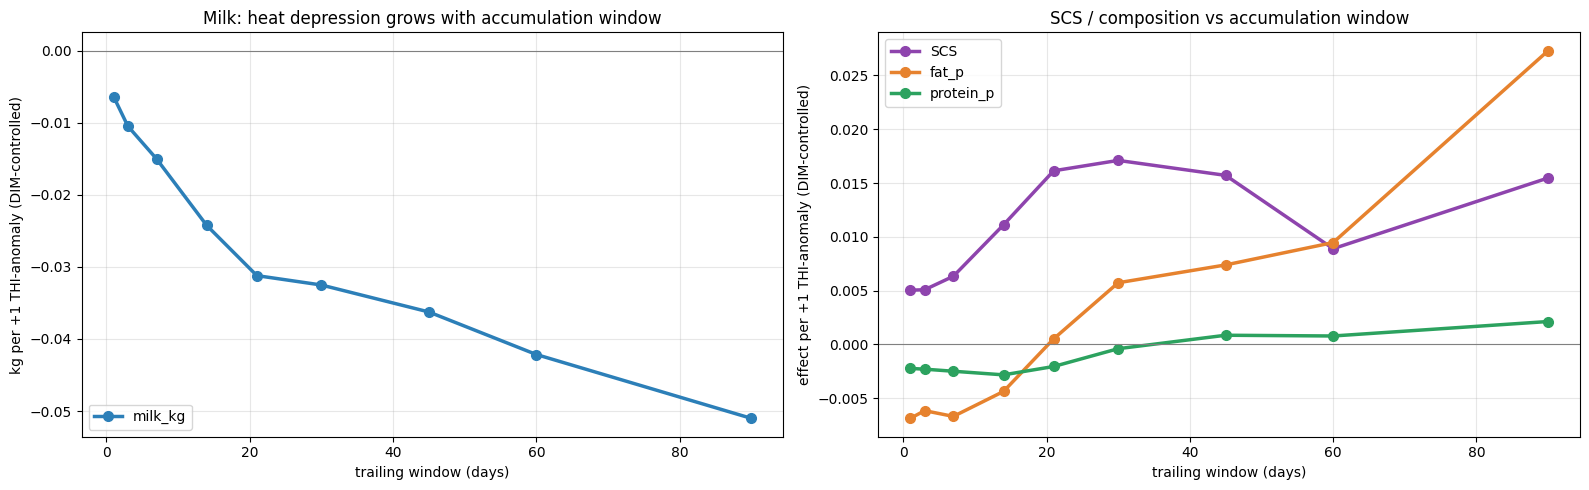

Read: where each curve is largest = the timescale over which heat most affects that trait.


In [8]:
fig,ax=plt.subplots(1,2,figsize=(16,5))
colors={'milk_kg':'#2c7fb8','SCS':'#8e44ad','fat_p':'#e6822e','protein_p':'#2ca25f'}
for t in ['milk_kg']:
    ax[0].plot(WINDOWS,prof[t],'o-',lw=2.5,ms=7,color=colors[t],label=t)
ax[0].axhline(0,color='gray',lw=.8); ax[0].set(title='Milk: heat depression grows with accumulation window',
    xlabel='trailing window (days)',ylabel='kg per +1 THI-anomaly (DIM-controlled)'); ax[0].grid(alpha=.3); ax[0].legend()
for t in ['SCS','fat_p','protein_p']:
    ax[1].plot(WINDOWS,prof[t],'o-',lw=2.5,ms=7,color=colors[t],label=t)
ax[1].axhline(0,color='gray',lw=.8); ax[1].set(title='SCS / composition vs accumulation window',
    xlabel='trailing window (days)',ylabel='effect per +1 THI-anomaly (DIM-controlled)'); ax[1].grid(alpha=.3); ax[1].legend()
plt.tight_layout(); plt.show()
print('Read: where each curve is largest = the timescale over which heat most affects that trait.')

## 3. Why DIM control matters — raw vs controlled
Longer windows correlate with later lactation stage. Without DIM control the SCS effect is inflated (late-lactation SCS masquerading as heat). This shows the difference so you can defend the smaller, honest number.

In [9]:
rows=[]
for t in ['milk_kg','SCS']:
    for win in [1,7,30,60]:
        x=f'anom_{win}d'
        br,_,_=fe_effect(summer,t,x,dim_control=False)
        bc,pc,n=fe_effect(summer,t,x,dim_control=True)
        rows.append({'target':t,'window':f'{win}d','no_control':br,'DIM_controlled':bc,'p(controlled)':pc,'n':n})
display(pd.DataFrame(rows).round(4))

,target,window,no_control,DIM_controlled,p(controlled),n
0,milk_kg,1d,-0.0025,-0.0064,0.0303,553175
1,milk_kg,7d,-0.0121,-0.0150,0.0001,553175
2,milk_kg,30d,-0.0343,-0.0325,0.0000,553175
3,milk_kg,60d,-0.0522,-0.0422,0.0000,553175
4,SCS,1d,0.0109,0.0050,0.0067,553175
5,SCS,7d,0.0157,0.0063,0.0068,553175
6,SCS,30d,0.0441,0.0171,0.0000,553175
7,SCS,60d,0.0432,0.0089,0.0830,553175


## 4. Best window per trait + effect in interpretable units

In [10]:
print('Most influential accumulation window per trait (|DIM-controlled effect| max):')
for t in TARGETS:
    arr=np.array(prof[t]); k=int(np.argmax(np.abs(arr))); win=WINDOWS[k]
    print(f'  {t:10s}: peak at {win:>2}d  (effect {arr[k]:+.4f} per THI-anomaly, p={pval[t][k]:.1e})')

# Interpretable: a sustained +5 THI-anomaly heatwave over its best window.
print('\nImpact of a sustained +5 THI-anomaly over the trait-specific best window:')
for t in TARGETS:
    arr=np.array(prof[t]); k=int(np.argmax(np.abs(arr)))
    unit='kg' if t=='milk_kg' else ('SCS' if t=='SCS' else '%')
    print(f'  {t:10s}: {arr[k]*5:+.3f} {unit}')

Most influential accumulation window per trait (|DIM-controlled effect| max):
  milk_kg   : peak at 90d  (effect -0.0510 per THI-anomaly, p=3.2e-07)
  SCS       : peak at 30d  (effect +0.0171 per THI-anomaly, p=1.3e-06)
  fat_p     : peak at 90d  (effect +0.0273 per THI-anomaly, p=1.1e-04)
  protein_p : peak at 14d  (effect -0.0028 per THI-anomaly, p=3.1e-07)

Impact of a sustained +5 THI-anomaly over the trait-specific best window:
  milk_kg   : -0.255 kg
  SCS       : +0.086 SCS
  fat_p     : +0.136 %
  protein_p : -0.014 %


## 5. (Optional) Distributed point-lags — immediate vs delayed
Instead of cumulative windows, this attaches the anomaly from *exactly* k days before the test-day, to see whether the response is immediate or delayed. Single-day anomalies are noisier than windows, so treat this as a robustness view.

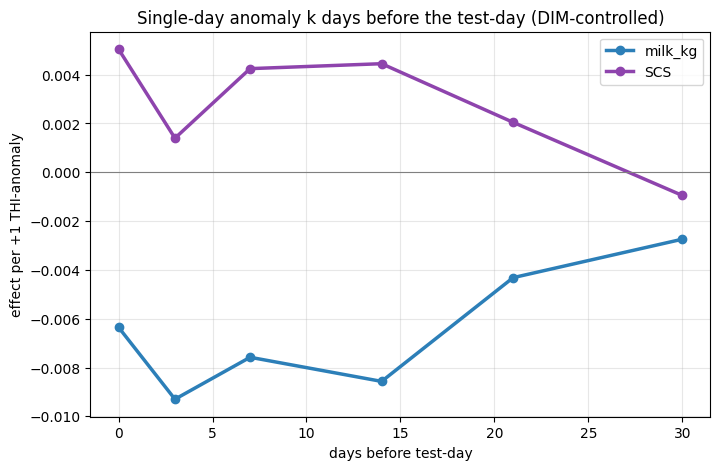

In [11]:
Wd=W[['farm','date','anom']].dropna().rename(columns={'anom':'anom0'})
lags=[0,3,7,14,21,30]
pl={'milk_kg':[],'SCS':[]}
for k in lags:
    tmp=Wd.copy(); tmp['date']=tmp['date']+pd.Timedelta(days=k)   # value k days BEFORE the test-day
    m=summer.merge(tmp.rename(columns={'anom0':'anom_lag'}),on=['farm','date'],how='left')
    for t in ['milk_kg','SCS']:
        b,_,_=fe_effect(m,t,'anom_lag',dim_control=True); pl[t].append(b)
fig,ax=plt.subplots(figsize=(8,5))
ax.plot(lags,pl['milk_kg'],'o-',color='#2c7fb8',lw=2.5,label='milk_kg')
ax.plot(lags,pl['SCS'],'o-',color='#8e44ad',lw=2.5,label='SCS')
ax.axhline(0,color='gray',lw=.8); ax.set(title='Single-day anomaly k days before the test-day (DIM-controlled)',
    xlabel='days before test-day',ylabel='effect per +1 THI-anomaly'); ax.grid(alpha=.3); ax.legend(); plt.show()

## 6. Takeaways

- **Heat is cumulative, not instantaneous.** Same-day THI badly understates the effect; the impact builds over weeks. This is the core reason raw single-day THI looked like 'no effect'.
- **Milk:** depression grows monotonically with the accumulation window and **survives DIM control** — a robust, real cumulative heat effect on yield.
- **SCS (udder health):** real positive effect that **peaks around a ~1-month accumulation**, but is much smaller once DIM is controlled — report the controlled number.
- **Composition (fat/protein):** weak / mixed; protein essentially flat.
- **For the prediction model (aim 6):** use the trait-specific best window (e.g. milk ← long accumulation, SCS ← ~30-day) as the climate feature, not same-day THI.
- **Caveat:** very long windows (60-90d) become collinear with season/lactation even after the anomaly + DIM control; lean on the 14-45d windows for the headline claims.